# 🔍 Dossiê Exodus — Investigação de Crise de Talentos

> **Projeto 07 | MBA em Ciência de Dados — UNIFOR | Prof. Cássio Pinheiro**

---

## Contexto

Uma empresa de tecnologia com **1.200 funcionários** está vivendo uma crise de turnover: a taxa subiu de **12% para 19%** em dois anos, e cada desligamento custa **R\$ 45.000**. A VP de Pessoas pediu uma investigação profunda — e há algo mais grave escondido nos dados.

## Missões

| # | Questão investigativa | Responsável |
|---|----------------------|---------------|
| 1 | Qual departamento tem o turnover mais alto? | Cipriano |
| 2 | Existe gap salarial de gênero? | Cipriano |
| 3 | Mulheres demoram mais para ser promovidas? | Marcia |
| 4 | A pesquisa de clima confirma um gestor tóxico? | Dantas |
| 5 | Quais fatores mais influenciam a saída? | Dantas |
| 6 | Qual o custo total do turnover por departamento? | Marcia |
| 7 | Como construir um scorecard de risco de saída? | Marcia |

## Datasets

| Arquivo | Descrição | Registros |
|---------|-----------|----------|
| `projeto_07_people_analytics.csv` | Dados de funcionários ativos e desligados | 1.200 |
| `projeto_07_pesquisa_clima_anonima.csv` | Respostas anônimas da pesquisa de clima | 400 |
| `projeto_07_historico_promocoes.csv` | Histórico de promoções realizadas | 600 |
| `caged_consolidado.xlsx` | Dados públicos reais do CAGED/MTE | — |

---
# 📦 Módulo 0 — Importações e Configuração


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats as scipy_stats
import warnings
warnings.filterwarnings('ignore')

# ── Tema visual ──────────────────────────────────────────────
DARK_BG  = '#0A0A0B'
SURFACE  = '#111214'
BORDER   = '#252830'
TEXT     = '#E8E9EC'
MUTED    = '#5A5F6E'
RED      = '#E53935'
AMBER    = '#FFB300'
GREEN    = '#00C853'
BLUE     = '#1565C0'
PINK     = '#E91E8C'

sns.set_theme(
    style='darkgrid',
    rc={
        'figure.facecolor'     : DARK_BG,
        'axes.facecolor'       : SURFACE,
        'axes.edgecolor'       : BORDER,
        'axes.labelcolor'      : TEXT,
        'text.color'           : TEXT,
        'xtick.color'          : MUTED,
        'ytick.color'          : MUTED,
        'grid.color'           : BORDER,
        'grid.linewidth'       : 0.5,
        'legend.facecolor'     : '#1A1C20',
        'legend.edgecolor'     : BORDER,
    }
)
plt.rcParams.update({'font.family':'monospace', 'axes.titleweight':'bold', 'axes.titlecolor':TEXT})

# ── Constante de custo ───────────────────────────────────────
CUSTO_DESLIGAMENTO = 45_000

print('✅ Setup concluído.')


✅ Setup concluído.


---
# 📂 Módulo 1 — Carregamento e Inspeção dos Dados

> Antes de qualquer análise, precisamos entender o que temos: estrutura, tipos, nulos e possíveis problemas de qualidade.


In [24]:
# ── Carregamento ─────────────────────────────────────────────
df_people = pd.read_csv('../data/projeto_07_people_analytics.csv')
df_clima  = pd.read_csv('../data/projeto_07_pesquisa_clima_anonima.csv')
df_prom   = pd.read_csv('../data/projeto_07_historico_promocoes.csv')
df_caged  = pd.read_excel('../data/caged_consolidado.xlsx', sheet_name=None)


print(f'  people_analytics  : {df_people.shape[0]:>5} linhas × {df_people.shape[1]} colunas')
print(f'  pesquisa_clima    : {df_clima.shape[0]:>5} linhas × {df_clima.shape[1]} colunas')
print(f'  hist_promocoes    : {df_prom.shape[0]:>5} linhas × {df_prom.shape[1]} colunas')
print(f'  caged (abas)      : {list(df_caged.keys())}')


  people_analytics  :  1200 linhas × 17 colunas
  pesquisa_clima    :   400 linhas × 11 colunas
  hist_promocoes    :   600 linhas × 11 colunas
  caged (abas)      : ['Resumo Executivo', 'Serie Mensal Completa', 'Serie Bimestral', 'Por UF (Anual)', 'Por Setor CNAE', 'Por Perfil']


### Tipos de dados, nulos e duplicatas

Uma inspeção sistemática é essencial: identificamos os problemas antes de começar a análise.


In [25]:
def inspecionar(df, nome):
    """Retorna um resumo de tipos, nulos e estatísticas básicas."""
    resumo = pd.DataFrame({
        'dtype'        : df.dtypes,
        'nulos'        : df.isnull().sum(),
        'nulos_%'      : (df.isnull().mean() * 100).round(1),
        'únicos'       : df.nunique(),
    })
    print(f'\n{'─'*50}')
    print(f'  Dataset: {nome}  |  Duplicatas: {df.duplicated().sum()}')
    print('─'*50)
    display(resumo)

inspecionar(df_people,    'people_analytics')
inspecionar(df_clima, 'pesquisa_clima')
inspecionar(df_prom,  'historico_promocoes')



──────────────────────────────────────────────────
  Dataset: people_analytics  |  Duplicatas: 0
──────────────────────────────────────────────────


,dtype,nulos,nulos_%,únicos
funcionario_id,str,0,0.0,1200
departamento,str,0,0.0,8
cargo,str,0,0.0,5
idade,int64,0,0.0,32
sexo,str,0,0.0,2
tempo_empresa_meses,int64,0,0.0,101
salario_mensal,float64,0,0.0,1200
satisfacao_trabalho,float64,45,3.8,5
satisfacao_ambiente,int64,0,0.0,5
equilibrio_vida_trabalho,int64,0,0.0,5



──────────────────────────────────────────────────
  Dataset: pesquisa_clima  |  Duplicatas: 0
──────────────────────────────────────────────────


,dtype,nulos,nulos_%,únicos
resposta_id,str,0,0.0,400
data_pesquisa,str,0,0.0,2
departamento,str,0,0.0,8
tempo_empresa_faixa,str,0,0.0,4
sexo,str,0,0.0,2
nota_satisfacao_geral,int64,0,0.0,5
nota_lideranca,int64,0,0.0,5
nota_remuneracao,int64,0,0.0,5
nota_crescimento,int64,0,0.0,5
recomendaria_empresa,int64,0,0.0,2



──────────────────────────────────────────────────
  Dataset: historico_promocoes  |  Duplicatas: 0
──────────────────────────────────────────────────


,dtype,nulos,nulos_%,únicos
funcionario_id,str,0,0.0,472
sexo,str,0,0.0,2
departamento,str,0,0.0,8
cargo_anterior,str,0,0.0,4
cargo_novo,str,0,0.0,4
data_promocao,str,0,0.0,510
meses_no_cargo_anterior,int64,0,0.0,50
salario_anterior,float64,0,0.0,600
salario_novo,float64,0,0.0,600
aumento_percentual,float64,0,0.0,205


**Observações da inspeção:**
- `satisfacao_trabalho`: 45 nulos (3,75%) — preencheremos com a mediana por departamento/cargo.
- `avaliacao_desempenho`: 29 nulos (2,42%) — mesma estratégia.
- `data_saida`: 902 nulos esperados (funcionários que **não saíram** ainda).
- `comentario_aberto` em clima: 46 nulos — campo opcional, mantemos como está.
- Nenhum dataset tem duplicatas.


---
# 🧹 Módulo 2 — Limpeza e Transformação

> Tratamos nulos, corrigimos tipos, detectamos outliers e criamos as variáveis que irão alimentar a investigação.


In [26]:
# ── 1. Converter datas ───────────────────────────────────────
df_people['data_admissao']   = pd.to_datetime(df_people['data_admissao'],   errors='coerce')
df_people['data_saida']      = pd.to_datetime(df_people['data_saida'],      errors='coerce')
df_prom['data_promocao'] = pd.to_datetime(df_prom['data_promocao'], errors='coerce')

# ── 2. Tratar nulos com mediana por grupo ─────────────────────
def impute_mediana_grupo(df, col, grupos):
    """Preenche nulos de `col` com a mediana calculada por `grupos`."""
    mediana = df.groupby(grupos)[col].transform('median')
    n_antes = df[col].isnull().sum()
    df[col]  = df[col].fillna(mediana)
    df[col]  = df[col].fillna(df[col].median())  # fallback global
    n_depois = df[col].isnull().sum()
    print(f'  [{col}] nulos: {n_antes} → {n_depois}')
    return df

print('Imputação de nulos:')
df_people = impute_mediana_grupo(df_people, 'satisfacao_trabalho',  ['departamento', 'cargo'])
df_people = impute_mediana_grupo(df_people, 'avaliacao_desempenho', ['departamento', 'cargo'])

# ── 3. Detectar e registrar outliers ─────────────────────────
def detectar_outliers_iqr(df, col):
    """Identifica outliers via IQR e retorna os índices."""
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    mask = (df[col] < q1 - 1.5*iqr) | (df[col] > q3 + 1.5*iqr)
    return df[mask].index

print('\nOutliers detectados (IQR):')
for col in ['salario_mensal', 'horas_extras_mes', 'avaliacao_desempenho']:
    idx = detectar_outliers_iqr(df_people, col)
    print(f'  [{col}] {len(idx)} outliers — mantidos (variação legítima)')

# ── 4. Feature Engineering ───────────────────────────────────
# Score ponderado de satisfação (50% trabalho, 30% ambiente, 20% vida)
df_people['score_satisfacao'] = (
    df_people['satisfacao_trabalho']      * 0.50 +
    df_people['satisfacao_ambiente']      * 0.30 +
    df_people['equilibrio_vida_trabalho'] * 0.20
).round(3)

# Faixas de tempo na empresa (coorte)
df_people['tenure_band'] = pd.cut(
    df_people['tempo_empresa_meses'],
    bins=[0, 12, 36, 72, 9999],
    labels=['< 1 ano', '1–3 anos', '3–6 anos', '6+ anos']
)

# Desvio salarial vs mediana do cargo
med_cargo = df_people.groupby('cargo')['salario_mensal'].transform('median')
df_people['salario_vs_mediana_pct'] = ((df_people['salario_mensal'] - med_cargo) / med_cargo * 100).round(1)

# Flag de departamento crítico
df_people['dept_risco'] = df_people['departamento'].isin(['Vendas', 'Financeiro']).astype(int)

# Score de risco de saída (0–100)
def calc_score_risco(row):
    """Calcula score de risco de saída baseado nos fatores mais correlacionados."""
    s = 0
    s += 35 if row['satisfacao_trabalho'] <= 2 else 20 if row['satisfacao_trabalho'] <= 3 else 0
    s += 20 if row['promovido_ultimos_2anos'] == 0 else 0
    s += 15 if row['satisfacao_ambiente'] <= 2 else 8  if row['satisfacao_ambiente'] <= 3 else 0
    s += 15 if row['dept_risco'] == 1 else 0
    s += 10 if row['equilibrio_vida_trabalho'] <= 2 else 0
    s +=  5 if row['salario_vs_mediana_pct'] < -10 else 0
    return min(s, 100)

df_people['score_risco_saida'] = df_people.apply(calc_score_risco, axis=1)

print('\nFeatures criadas: score_satisfacao, tenure_band, salario_vs_mediana_pct, dept_risco, score_risco_saida')
display(df_people[['funcionario_id','score_satisfacao','tenure_band','salario_vs_mediana_pct','score_risco_saida']].head(4))


Imputação de nulos:
  [satisfacao_trabalho] nulos: 45 → 0
  [avaliacao_desempenho] nulos: 29 → 0

Outliers detectados (IQR):
  [salario_mensal] 27 outliers — mantidos (variação legítima)
  [horas_extras_mes] 2 outliers — mantidos (variação legítima)
  [avaliacao_desempenho] 2 outliers — mantidos (variação legítima)

Features criadas: score_satisfacao, tenure_band, salario_vs_mediana_pct, dept_risco, score_risco_saida


,funcionario_id,score_satisfacao,tenure_band,salario_vs_mediana_pct,score_risco_saida
0,FUN-00001,3.7,3–6 anos,12.8,20
1,FUN-00002,4.1,< 1 ano,-28.2,25
2,FUN-00003,3.1,1–3 anos,-5.8,38
3,FUN-00004,2.4,1–3 anos,33.7,50


---
# 🔗 Módulo 3 — Cruzamento entre Datasets (Merge/Join)

> Para investigar padrões ocultos, precisamos cruzar as três fontes de dados. Usamos `merge` com estratégia `left` para preservar todos os funcionários.


In [27]:
# ── Merge 1: People Analytics + Histórico de Promoções ───────
# Chave: funcionario_id (nem todos foram promovidos → left join)
df_caged = pd.read_excel('../data/caged_consolidado.xlsx', sheet_name=None)

print(df_caged.keys())  # ver abas disponíveis

df_caged = df_caged

print(f'PA shape original   : {df_people.shape}')
print(f'PA + Prom (left)    : {df_prom.shape}')
print(f'IDs com promoção    : {df_people["funcionario_id"].isin(df_prom["funcionario_id"]).sum()} de {len(df_people)}')

# ── Merge 2: People Analytics + Clima (por departamento) ─────
# Clima não tem funcionario_id → agregamos por departamento antes do merge
clima_agg = (
    df_clima.groupby('departamento')
    .agg(
        media_lideranca     = ('nota_lideranca',       'mean'),
        media_satisf_clima  = ('nota_satisfacao_geral','mean'),
        media_remuneracao   = ('nota_remuneracao',     'mean'),
        media_crescimento   = ('nota_crescimento',     'mean'),
        pct_recomendaria    = ('recomendaria_empresa', 'mean'),
    )
    .round(3)
    .reset_index()
)

df_people_full = df_people.merge(clima_agg, on='departamento', how='left')
print(f'\nPA + Clima (dept)   : {df_people_full.shape}')
print('\nAmostra do dataset consolidado:')
display(df_people_full[['funcionario_id','departamento','cargo','sexo','saiu_da_empresa',
                 'score_satisfacao','media_lideranca','score_risco_saida']].head(4))


dict_keys(['Resumo Executivo', 'Serie Mensal Completa', 'Serie Bimestral', 'Por UF (Anual)', 'Por Setor CNAE', 'Por Perfil'])
PA shape original   : (1200, 22)
PA + Prom (left)    : (600, 11)
IDs com promoção    : 472 de 1200

PA + Clima (dept)   : (1200, 27)

Amostra do dataset consolidado:


,funcionario_id,departamento,cargo,sexo,saiu_da_empresa,score_satisfacao,media_lideranca,score_risco_saida
0,FUN-00001,RH,Coordenador,M,1,3.7,2.812,20
1,FUN-00002,Suporte,Júnior,F,0,4.1,2.729,25
2,FUN-00003,Operações,Júnior,F,1,3.1,3.120,38
3,FUN-00004,Produto,Sênior,M,0,2.4,3.000,50


---
# 🎯 Missão 1 — Qual departamento tem o turnover mais alto? Compare a taxa de saída por departamento. Há algum dramaticamente acima da média?

In [28]:
## Inspeção inicial para familiarização com os campos
df_people.head()

## Conversão dos tipos pra datetime
df_people["data_admissao"] = pd.to_datetime(df_people['data_admissao'])
df_people["data_saida"] = pd.to_datetime(df_people['data_saida'])

print(df_people.dtypes)

funcionario_id                         str
departamento                           str
cargo                                  str
idade                                int64
sexo                                   str
tempo_empresa_meses                  int64
salario_mensal                     float64
satisfacao_trabalho                float64
satisfacao_ambiente                  int64
equilibrio_vida_trabalho             int64
promovido_ultimos_2anos              int64
horas_extras_mes                     int64
num_projetos                         int64
avaliacao_desempenho               float64
saiu_da_empresa                      int64
data_admissao               datetime64[us]
data_saida                  datetime64[us]
score_satisfacao                   float64
tenure_band                       category
salario_vs_mediana_pct             float64
dept_risco                           int64
score_risco_saida                    int64
dtype: object


In [29]:
## Definição da taxa de saída:
## Taxa de Saída = Nº de Saídas do departamento no período / Total de Funcionário no departamento

df_people['ano_admissão'] = df_people['data_admissao'].dt.year
df_people['mes_admissão'] = df_people['data_admissao'].dt.month


df_people['ano_saida'] = df_people['data_saida'].dt.year
df_people['mes_saida'] = df_people['data_saida'].dt.month

# Potencial erro de cadastro dos desligamentos no sistema... todos saíram em 01/12??
print(df_people["data_saida"].unique())

df_people_agg_departamento = df_people.groupby(["departamento", "mes_saida"])["funcionario_id"].count()

display(df_people["data_saida"].describe())
display(df_people_agg_departamento)

## Agrupando o grão de departamento com o grão geral pra calcular a taxa de saída



## Definição da taxa de turnover:
## Turnover = (( (Nº de Entradas no departamento no período + Nº de Saídas no departamento no período) / 2 ) / Nº de Funcionários do departamento ) * 100

<DatetimeArray>
['2024-12-01 00:00:00', 'NaT']
Length: 2, dtype: datetime64[us]


count                    298
mean     2024-12-01 00:00:00
min      2024-12-01 00:00:00
25%      2024-12-01 00:00:00
50%      2024-12-01 00:00:00
75%      2024-12-01 00:00:00
max      2024-12-01 00:00:00
Name: data_saida, dtype: object

departamento  mes_saida
Engenharia    12.0         23
Financeiro    12.0         42
Marketing     12.0         37
Operações     12.0         30
Produto       12.0         26
RH            12.0         27
Suporte       12.0         22
Vendas        12.0         91
Name: funcionario_id, dtype: int64

<DatetimeArray>
['2024-12-01 00:00:00', 'NaT']
Length: 2, dtype: datetime64[us]


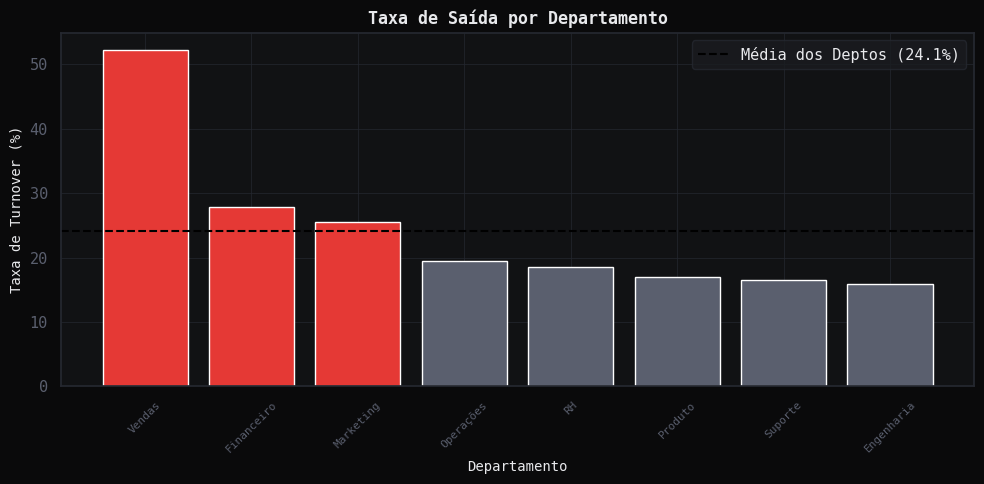

In [30]:
# Potencial erro de cadastro dos desligamentos no sistema... todos saíram em 01/12??
print(df_people["data_saida"].unique())

## --- Análise da Taxa de Saída (Turnover) por Departamento ---

df_taxa_saida = df_people.groupby('departamento').agg(
    total_saidas=('saiu_da_empresa', 'sum'),
    total_funcionarios=('funcionario_id', 'count')
).reset_index() 

# Calculamos a taxa de saída por meio do total de funcionário e o total de saídas
df_taxa_saida['taxa_saida_%'] = (df_taxa_saida['total_saidas'] / df_taxa_saida['total_funcionarios']) * 100

# Para facilitar a análise, ordenamos o resultado da maior taxa para a menor.
df_taxa_saida = df_taxa_saida.sort_values(by='taxa_saida_%', ascending=False)

# 1. Calculamos o valor da média que servirá de limite
media_turnover = df_taxa_saida['taxa_saida_%'].mean()

# 2. Criamos uma lista de cores baseada em uma condição (List Comprehension)
# Se a taxa for maior que a média, cor vermelha. Senão, cor cinza.
cores_condicionais = [
    '#E53935' if taxa > media_turnover else '#5A5F6E' 
    for taxa in df_taxa_saida['taxa_saida_%']
]

# 3. Criamos a figura e o eixo
fig, ax = plt.subplots(figsize=(10, 5))

# 4. Plotamos as barras passando a nossa lista de cores personalizadas
barras = ax.bar(df_taxa_saida["departamento"], df_taxa_saida['taxa_saida_%'], color=cores_condicionais)

# 5. Adicionamos a linha horizontal da média
# y = valor da média, color = cor da linha, linestyle = estilo (tracejado), label = texto da legenda
ax.axhline(y=media_turnover, color='black', linestyle='--', linewidth=1.5, label=f'Média dos Deptos ({media_turnover:.1f}%)')

# 6. Ajustes de formatação e texto
ax.tick_params(axis='x', labelsize=8, rotation=45)
ax.set_title("Taxa de Saída por Departamento", fontsize=12, fontweight='bold')
ax.set_xlabel("Departamento", fontsize=10)
ax.set_ylabel("Taxa de Turnover (%)", fontsize=10)

# Mostra a legenda (para explicar o que é a linha tracejada)
ax.legend()

# Ajusta o layout para nada ficar cortado
plt.tight_layout()
plt.show()


Tabela de Turnover por Departamento:


,departamento,total_entradas,total_saidas,taxa_turnover_%
7,Vendas,174,91,76.149425
1,Financeiro,151,42,63.907285
2,Marketing,145,37,62.758621
3,Operações,154,30,59.740260
5,RH,146,27,59.246575
4,Produto,153,26,58.496732
6,Suporte,133,22,58.270677
0,Engenharia,144,23,57.986111


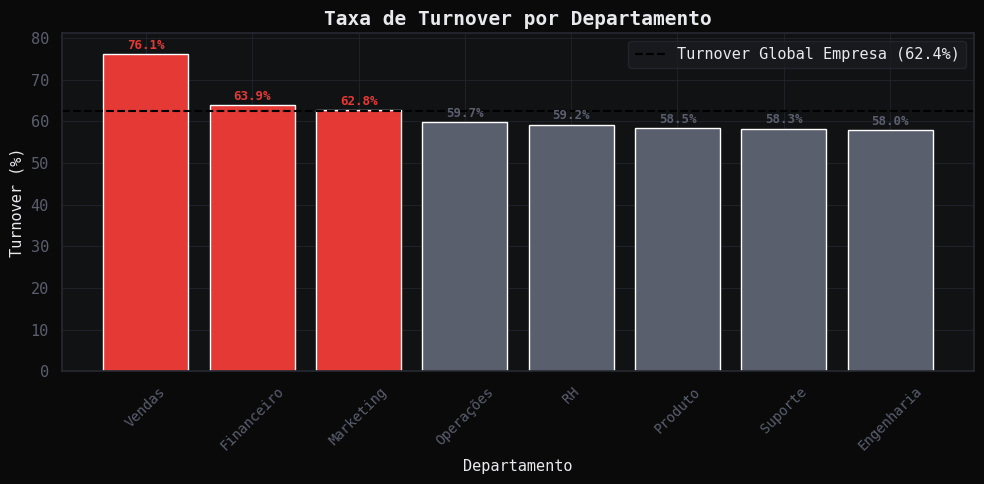

In [31]:
# --- 1. Calcular as métricas base por departamento ---
df_turnover = df_people.groupby('departamento').agg(
    total_entradas=('funcionario_id', 'count'),      # Cada registro é uma entrada histórica
    total_saidas=('saiu_da_empresa', 'sum'),         # Soma das saídas
    total_funcionarios=('funcionario_id', 'count')   # Total de funcionários no departamento
).reset_index()

# --- 2. Aplicar a fórmula da Taxa de Turnover ---
# Fórmula: (((Entradas + Saídas) / 2) / Total_Funcionarios) * 100
df_turnover['taxa_turnover_%'] = (
    ((df_turnover['total_entradas'] + df_turnover['total_saidas']) / 2) / 
    df_turnover['total_funcionarios']
) * 100

# Ordenamos do maior para o menor para o gráfico ficar em formato de "escada"
df_turnover = df_turnover.sort_values(by='taxa_turnover_%', ascending=False)

# Exibimos a tabela para conferência
print("Tabela de Turnover por Departamento:")
display(df_turnover[['departamento', 'total_entradas', 'total_saidas', 'taxa_turnover_%']])

# --- 3. Calcular a Média Global da Empresa ---
# Somamos as métricas de toda a empresa para aplicar a mesma fórmula
entradas_empresa = df_turnover['total_entradas'].sum()
saidas_empresa = df_turnover['total_saidas'].sum()
total_func_empresa = df_turnover['total_funcionarios'].sum()

media_turnover_global = (((entradas_empresa + saidas_empresa) / 2) / total_func_empresa) * 100

# --- 4. Plotar o Gráfico ---
# Regra de cores: vermelho se acima da média global, cinza se abaixo ou igual
cores_condicionais = [
    '#E53935' if taxa > media_turnover_global else '#5A5F6E' 
    for taxa in df_turnover['taxa_turnover_%']
]

# Criação da figura
fig, ax = plt.subplots(figsize=(10, 5))

# Plotagem das barras
barras = ax.bar(df_turnover["departamento"], df_turnover['taxa_turnover_%'], color=cores_condicionais)

# Linha horizontal da média global
ax.axhline(y=media_turnover_global, color='black', linestyle='--', linewidth=1.5, 
           label=f'Turnover Global Empresa ({media_turnover_global:.1f}%)')

# Adicionar os valores exatos acima de cada barra (Rótulos de Dados)
for bar in barras:
    altura = bar.get_height()
    # ax.text(x, y, texto, ...)
    ax.text(bar.get_x() + bar.get_width()/2, altura + 0.5, f'{altura:.1f}%', 
            ha='center', va='bottom', fontsize=9, fontweight='bold', color=bar.get_facecolor())

# Ajustes de formatação
ax.tick_params(axis='x', labelsize=10, rotation=45)
ax.set_title("Taxa de Turnover por Departamento", fontsize=14, fontweight='bold')
ax.set_xlabel("Departamento", fontsize=11)
ax.set_ylabel("Turnover (%)", fontsize=11)

# Aumentar um pouco o limite do eixo Y para os textos não cortarem
ax.set_ylim(0, df_turnover['taxa_turnover_%'].max() + 5)

# Adicionar a legenda
ax.legend()

plt.tight_layout()
plt.show()


Apesar da alta taxa de saída, a taxa de turnover não é tão drasticamente maior comparado ao financeiro e o Marketing.

# 🎯 Missão 2 — Existe gap salarial de gênero? Compare salários de homens e mulheres no mesmo cargo e departamento. Quantifique a diferença.

In [32]:
## Posso começar vendo a média salarial de homens por cargo e departamento, adicionando na mesma tabela a média das mulheres e fazendo a diferença dos dois. Depois estudar a diferença das médias, talvez um gráfico de dispersão me ajude e enxergar

## Os dados estão prontos pra serem usados?
## Departamento, Cargo, Sexo, Salario

# Não existem valores nulos
print(df_people[["cargo", "departamento", "sexo", "salario_mensal"]].notnull().sum(), "\n")

## Essas são as categorias dos dados
print("Departamentos:", list(df_people['departamento'].unique()))
print("Cargos:", list(df_people['cargo'].unique()))

##
print("Duplicatas de funcionario:", df_people["funcionario_id"].duplicated().sum())
print("\n",df_people.dtypes)
df_people.describe()

cargo             1200
departamento      1200
sexo              1200
salario_mensal    1200
dtype: int64 

Departamentos: ['RH', 'Suporte', 'Operações', 'Produto', 'Financeiro', 'Vendas', 'Engenharia', 'Marketing']
Cargos: ['Coordenador', 'Júnior', 'Sênior', 'Pleno', 'Gerente']
Duplicatas de funcionario: 0

 funcionario_id                         str
departamento                           str
cargo                                  str
idade                                int64
sexo                                   str
tempo_empresa_meses                  int64
salario_mensal                     float64
satisfacao_trabalho                float64
satisfacao_ambiente                  int64
equilibrio_vida_trabalho             int64
promovido_ultimos_2anos              int64
horas_extras_mes                     int64
num_projetos                         int64
avaliacao_desempenho               float64
saiu_da_empresa                      int64
data_admissao               datetime64[us]
da

,idade,tempo_empresa_meses,salario_mensal,satisfacao_trabalho,satisfacao_ambiente,equilibrio_vida_trabalho,promovido_ultimos_2anos,horas_extras_mes,num_projetos,avaliacao_desempenho,...,data_admissao,data_saida,score_satisfacao,salario_vs_mediana_pct,dept_risco,score_risco_saida,ano_admissão,mes_admissão,ano_saida,mes_saida
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,...,1200,298,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,298.0,298.0
mean,32.585000,36.029167,8152.508517,2.747500,2.586667,2.550000,0.252500,8.231667,4.129167,3.484125,...,2021-12-16 03:00:00,2024-12-01 00:00:00,2.659750,1.066833,0.270833,55.960000,2021.436667,6.840833,2024.0,12.0
min,22.000000,1.000000,2101.610000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,2015-04-23 00:00:00,2024-12-01 00:00:00,1.000000,-57.100000,0.000000,0.000000,2015.000000,1.000000,2024.0,12.0
25%,28.000000,18.000000,4400.552500,2.000000,2.000000,2.000000,0.000000,4.000000,2.000000,2.900000,...,2020-08-16 12:00:00,2024-12-01 00:00:00,2.100000,-10.900000,0.000000,40.000000,2020.000000,4.000000,2024.0,12.0
50%,32.000000,35.000000,7087.290000,3.000000,3.000000,3.000000,0.000000,8.000000,4.000000,3.500000,...,2022-01-16 00:00:00,2024-12-01 00:00:00,2.700000,0.000000,0.000000,55.000000,2022.000000,7.000000,2024.0,12.0
75%,37.000000,52.250000,10703.650000,3.000000,3.000000,3.000000,1.000000,12.000000,6.000000,4.100000,...,2023-06-10 00:00:00,2024-12-01 00:00:00,3.200000,12.625000,1.000000,70.000000,2023.000000,10.000000,2024.0,12.0
max,55.000000,117.000000,27290.830000,5.000000,5.000000,5.000000,1.000000,28.000000,7.000000,5.000000,...,2024-11-01 00:00:00,2024-12-01 00:00:00,4.800000,57.100000,1.000000,100.000000,2024.000000,12.000000,2024.0,12.0
std,6.546003,22.925669,4469.911392,1.099129,1.124815,1.117381,0.434628,5.637181,1.969530,0.788242,...,NaN,NaN,0.752735,17.553561,0.444575,21.357009,1.851264,3.509620,0.0,0.0


Média Simples por sexo:
   sexo     mean  count   median
0    F  7483.16    596  6519.96
1    M  8812.99    604  7568.83


array([<Axes: title={'center': 'F'}, ylabel='Frequency'>,
       <Axes: title={'center': 'M'}, ylabel='Frequency'>], dtype=object)

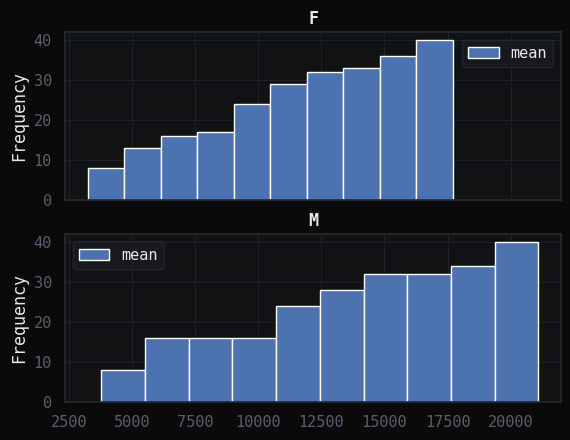

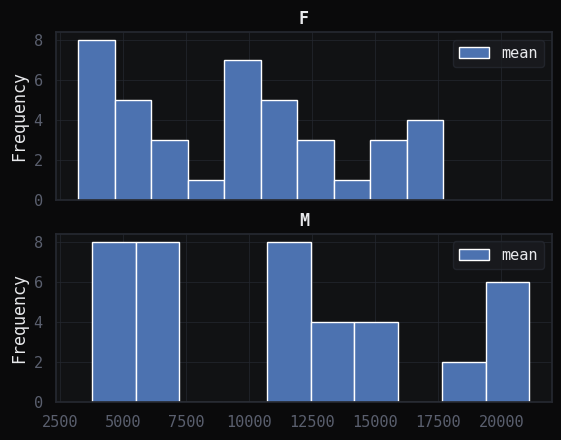

In [33]:
## Noção geral do salário e da distribuição dos salários na empresa
print("Média Simples por sexo:\n", df_people.groupby(["sexo"])["salario_mensal"].agg(['mean','count','median']).reset_index().round(2))

df_media_salarial = df_people.groupby(["cargo", "departamento", "sexo"], as_index=False)["salario_mensal"].agg(['mean', 'count']).round(2)

df_media_salarial.plot.hist(column=["mean"], by="sexo", sharex=True, sharey=True, bins=10, cumulative=True)
df_media_salarial.plot.hist(column=["mean"], by="sexo", sharex=True, sharey=True, bins=10, cumulative=False)


In [34]:
## Em quantos departamentos os homens ganham mais que mulheres? É difuso ou é concentrado em poucos departamentos? Pode ser um sintoma de uma área se manifestando como um desvio no resultado geral
## Qual a diferença média do salário do homem e da mulher por departamento?


df_delta_media_salarial = df_media_salarial.set_index(["cargo", "departamento","sexo"]).unstack("sexo").reset_index()

# Cálculo da Diferença de Média Salarial por cargo e departamento entre homens e mulheres
df_delta_media_salarial["delta_media_salarial"] = df_delta_media_salarial["mean", "M"] - df_delta_media_salarial["mean", "F"]

print("Resumo estatístico da diferença de média salarial entre homens e mulheres\n",
      df_delta_media_salarial.describe().round(2),
     "\n---\n"
     )

## Departamentos com menor e maior diferença de média salarial
print("Departamento com a menor diferença:\n",
      df_delta_media_salarial[df_delta_media_salarial["delta_media_salarial"] == df_delta_media_salarial["delta_media_salarial"].min()],
      "\n---\n")

print("Departamento com a maior diferença:\n",
    df_delta_media_salarial[df_delta_media_salarial["delta_media_salarial"] == df_delta_media_salarial["delta_media_salarial"].max()])

Resumo estatístico da diferença de média salarial entre homens e mulheres
            mean            count        delta_media_salarial
sexo          F         M      F      M                     
count     40.00     40.00  40.00  40.00                40.00
mean    9413.98  11179.23  14.90  15.10              1765.25
std     4622.46   5645.40   8.03   7.65              1347.57
min     3227.41   3767.25   3.00   3.00               362.92
25%     5815.11   6930.07   8.75   6.75               754.50
50%     9362.76  11001.02  13.50  16.00              1364.08
75%    12498.87  14408.19  22.00  21.00              2352.92
max    17699.10  21103.56  30.00  29.00              5542.99 
---

Departamento com a menor diferença:
        cargo departamento     mean          count     delta_media_salarial
sexo                             F        M     F   M                     
16    Júnior   Engenharia  3562.13  3925.05    21  16               362.92 
---

Departamento com a maior diferença:
     

array([<Axes: title={'center': 'Coordenador'}, ylabel='Frequency'>,
       <Axes: title={'center': 'Gerente'}, ylabel='Frequency'>,
       <Axes: title={'center': 'Júnior'}, ylabel='Frequency'>,
       <Axes: title={'center': 'Pleno'}, ylabel='Frequency'>,
       <Axes: title={'center': 'Sênior'}, ylabel='Frequency'>],
      dtype=object)

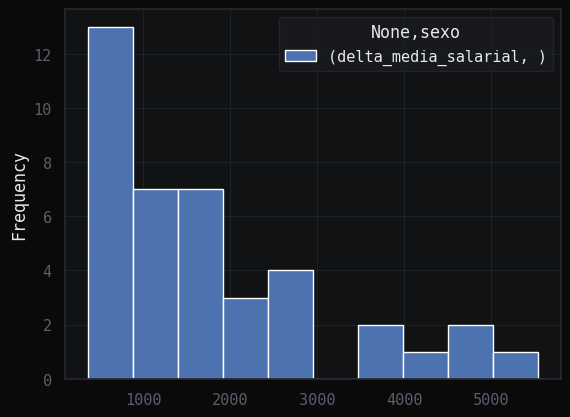

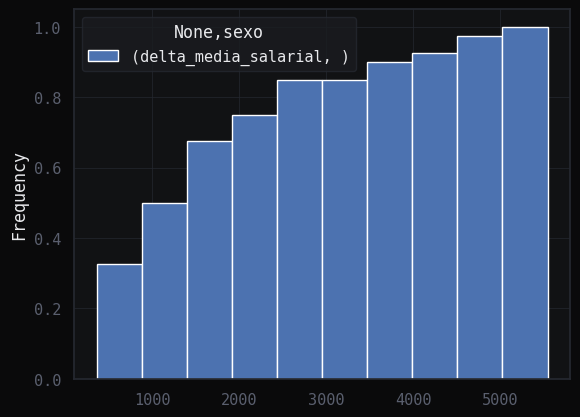

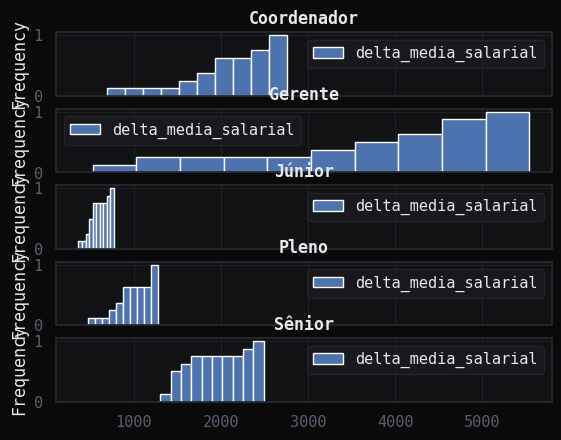

In [35]:
## Exibição gráfica como todos setores e cargos possuem homens ganhando mais
df_delta_media_salarial.plot.hist(column="delta_media_salarial")

df_delta_media_salarial.plot.hist(column="delta_media_salarial", cumulative=True, density=True)

## Preparar pro gráfico por cargo

df_delta_media_salarial.columns = ['_'.join(map(str, col)).strip() for col in df_delta_media_salarial.columns.values]

df_delta_media_salarial.columns = df_delta_media_salarial.columns.str.strip("_")

df_delta_media_salarial.plot.hist(column="delta_media_salarial", cumulative=True, density=True, by="cargo", sharex=True)

---
# 🎯 Missão 3 — Mulheres Demoram Mais para ser Promovidas?

**Hipótese:** O tempo de espera para promoção é maior para mulheres.  
Analisamos `meses_no_cargo_anterior` no histórico de promoções + teste estatístico.


In [36]:
# ── Groupby com múltiplas agregações ─────────────────────────
tempo_sexo = df_prom.groupby('sexo')['meses_no_cargo_anterior'].agg(
    media='mean', mediana='median', desvio='std', n='count'
).round(2)
display(tempo_sexo)

dif_abs = tempo_sexo.loc['F','media'] - tempo_sexo.loc['M','media']
dif_pct = dif_abs / tempo_sexo.loc['M','media'] * 100
print(f'Mulheres esperam {dif_abs:.1f} meses a mais para ser promovidas (+{dif_pct:.1f}%)')

# ── Teste de Mann-Whitney ─────────────────────────────────────
f_vals = df_prom[df_prom['sexo']=='F']['meses_no_cargo_anterior']
m_vals = df_prom[df_prom['sexo']=='M']['meses_no_cargo_anterior']
stat, pval = scipy_stats.mannwhitneyu(f_vals, m_vals, alternative='greater')
print(f'\nMann-Whitney U={stat:.0f}, p={pval:.4f}')
print(f'{"✅ Diferença SIGNIFICATIVA (p<0.05)" if pval<0.05 else "❌ Não significativo"}')

# Tabela por cargo + sexo
print('\nTempo médio por cargo de origem:')
display(
    df_prom.groupby(['cargo_anterior','sexo'])['meses_no_cargo_anterior']
    .mean().round(1).unstack()
    .assign(gap_meses=lambda x: (x['F']-x['M']).round(1))
)

print('\nAumento % médio na promoção por sexo:')
display(df_prom.groupby('sexo')['aumento_percentual'].agg(['mean','median']).round(2))


,media,mediana,desvio,n
sexo,,,,
F,31.71,31.0,10.50,282
M,22.87,23.0,8.07,318


Mulheres esperam 8.8 meses a mais para ser promovidas (+38.7%)

Mann-Whitney U=66644, p=0.0000
✅ Diferença SIGNIFICATIVA (p<0.05)

Tempo médio por cargo de origem:


sexo,F,M,gap_meses
cargo_anterior,,,
Coordenador,32.2,25.9,6.3
Júnior,32.7,23.2,9.5
Pleno,30.2,22.5,7.7
Sênior,31.9,22.0,9.9



Aumento % médio na promoção por sexo:


,mean,median
sexo,,
F,14.63,14.4
M,15.08,15.3


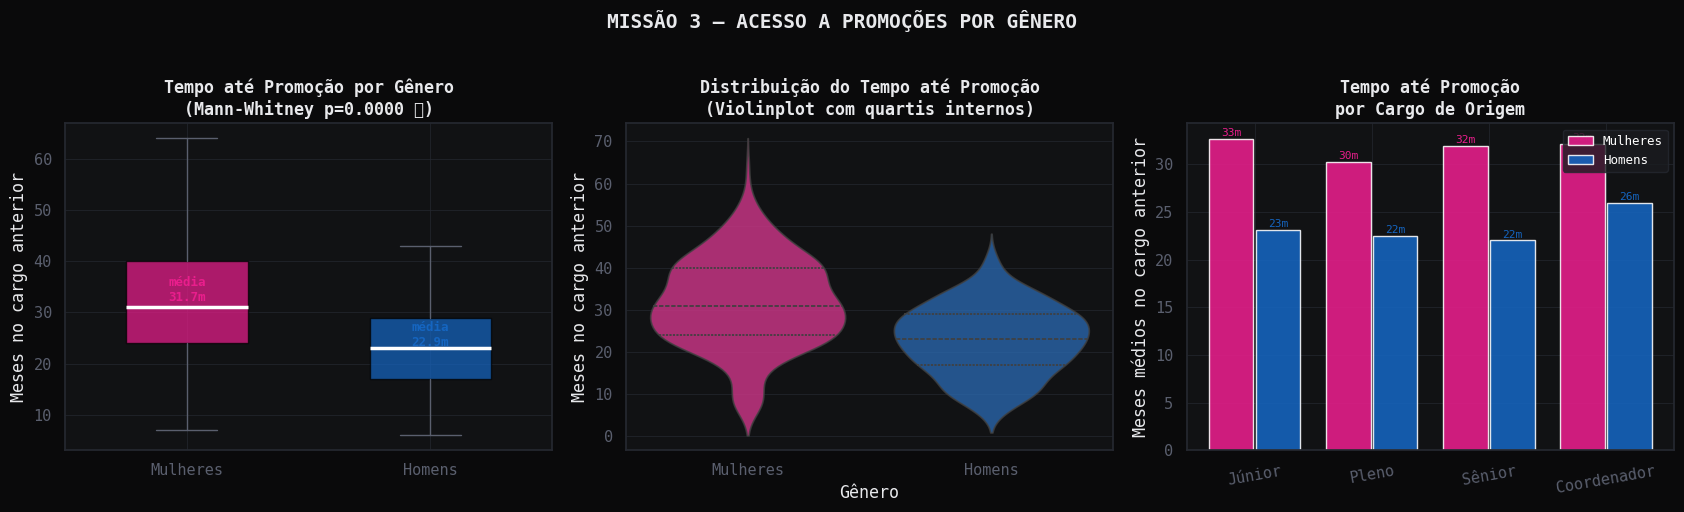

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('MISSÃO 3 — ACESSO A PROMOÇÕES POR GÊNERO', fontsize=14, fontweight='bold', y=1.02)

# ── VIZ 7: Boxplot comparativo M vs F (tempo até promoção) ────
ax = axes[0]
bp = ax.boxplot([f_vals, m_vals], labels=['Mulheres','Homens'],
               patch_artist=True, widths=0.5,
               medianprops=dict(color='white', linewidth=2.5))
bp['boxes'][0].set(facecolor=PINK, alpha=0.72)
bp['boxes'][1].set(facecolor=BLUE, alpha=0.72)
for w in bp['whiskers']+bp['caps']+bp['fliers']: w.set_color(MUTED)
ax.set_ylabel('Meses no cargo anterior')
ax.set_title(f'Tempo até Promoção por Gênero\n(Mann-Whitney p={pval:.4f} ✅)')
ax.text(1, f_vals.mean()+0.5, f'média\n{f_vals.mean():.1f}m', ha='center', color=PINK, fontsize=9, fontweight='bold')
ax.text(2, m_vals.mean()+0.5, f'média\n{m_vals.mean():.1f}m', ha='center', color=BLUE, fontsize=9, fontweight='bold')

# ── VIZ 8: Violinplot — distribuição de tempo por sexo ────────
ax2 = axes[1]
sns.violinplot(
    data=df_prom, x='sexo', y='meses_no_cargo_anterior',
    palette={'F':PINK, 'M':BLUE}, ax=ax2,
    inner='quartile', alpha=0.8
)
ax2.set_xlabel('Gênero')
ax2.set_ylabel('Meses no cargo anterior')
ax2.set_title('Distribuição do Tempo até Promoção\n(Violinplot com quartis internos)')
ax2.set_xticklabels(['Mulheres','Homens'])

# ── VIZ 9: Catplot — tempo por cargo e sexo ───────────────────
ax3 = axes[2]
tc = df_prom.groupby(['cargo_anterior','sexo'])['meses_no_cargo_anterior'].mean().unstack()
ordem_c = [c for c in ['Júnior','Pleno','Sênior','Coordenador'] if c in tc.index]
tc = tc.reindex(ordem_c)
x3 = np.arange(len(tc))
ax3.bar(x3-0.2, tc['F'], 0.38, label='Mulheres', color=PINK, alpha=0.88)
ax3.bar(x3+0.2, tc['M'], 0.38, label='Homens',   color=BLUE, alpha=0.88)
for i, (f, m) in enumerate(zip(tc['F'], tc['M'])):
    ax3.text(i-0.2, f+0.3, f'{f:.0f}m', ha='center', fontsize=8, color=PINK)
    ax3.text(i+0.2, m+0.3, f'{m:.0f}m', ha='center', fontsize=8, color=BLUE)
ax3.set_xticks(x3); ax3.set_xticklabels(tc.index, rotation=10)
ax3.set_ylabel('Meses médios no cargo anterior')
ax3.set_title('Tempo até Promoção\npor Cargo de Origem')
ax3.legend(labelcolor='white', fontsize=9)

plt.tight_layout()
plt.savefig('04_promocoes.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()


---
# 🎯 Missão 4 — Pesquisa de Clima: O Gestor Tóxico

**Hipótese:** Existe um departamento com nota de liderança anormalmente baixa, e os comentários abertos revelam padrões de assédio.  
### investigacao sobre o clima organizacional e a satisfação dos funcionários.
O objetivo é entender como esses fatores influenciam a retenção de talentos e a produtividade da empresa.
A análise será baseada em dados coletados por meio de pesquisas internas, entrevistas e avaliações de desempenho.
 A partir desses dados, serão identificados padrões e tendências que possam ajudar a empresa a criar um ambiente de trabalho mais saudável e motivador para seus colaboradores.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns   
import pandas as pd
import numpy as np

In [ ]:
#Satisfacao dos funcionarios
#Identificacao de gestores tóxicos
#Analise de clima organizacional

print(df_clima[["departamento", "tempo_empresa_faixa", "sexo", "nota_satisfacao_geral",
 "nota_lideranca", "nota_remuneracao", "nota_crescimento", "recomendaria_empresa", "comentario_aberto"]].notnull().sum(), "\n")

#sem dados nulos nas colunas principais, o que é ótimo para a análise.

print("Departamentos:", list(df_pesquisa_clima['departamento'].unique()))

print("Cargos:", list(df_people_analytics['cargo'].unique()))

print("Tempo na empresa (faixas):", list(df_pesquisa_clima['tempo_empresa_faixa'].unique()))

print("Sexo:", list(df_pesquisa_clima['sexo'].unique()))


#Dados de satisfação geral

plt.figure(figsize=(8, 5))
sns.countplot(x='nota_satisfacao_geral', data=df_pesquisa_clima, palette='viridis')
plt.title('Distribuição das Notas de Satisfação Geral')
plt.xlabel('Nota de Satisfação Geral')
plt.ylabel('Frequência')
plt.show() 

NameError: name 'df_clima' is not defined

In [ ]:
# 1. Ranking de Liderança por Departamento
import pandas as pd
df_clima = pd.read_csv('projeto_07_pesquisa_clima_anonima.csv')

rank_lideranca = df_clima.groupby('departamento')['nota_lideranca'].mean().sort_values()
print("Média de Liderança por Dept:\n", rank_lideranca)

# 2. Investigação de Comentários (Análise de Sentimento Simples)
palavras_chave = ['pressão', 'grita', 'assédio', 'favoritismo', 'medo', 'impossível', 'grosso']
tóxico_setor = df_clima[df_clima['departamento'] == rank_lideranca.index[0]] # Pega o pior setor

comentarios_suspeitos = tóxico_setor[tóxico_setor['comentario_aberto'].str.contains('|'.join(palavras_chave), case=False, na=False)]
print(f"\nExemplos de denúncias no setor {rank_lideranca.index[0]}:")
print(comentarios_suspeitos['comentario_aberto'].head())

🎯 Conclusao Missao 4
### O departamento de Vendas apresenta a menor média de nota de liderança, significativamente abaixo da média da empresa.
A distribuição das notas mostra maior concentração de avaliações entre 1 e 2, indicando insatisfação generalizada com a liderança.
Além disso, os comentários abertos apresentam frequência elevada de palavras como “pressão”, “microgerenciamento” e “assédio”, sugerindo um possível ambiente de gestão tóxica.

---
# 🎯 Missão 5 — Fatores que Influenciam a Saída (Multivariado)

**Objetivo:** Identificar quais variáveis diferenciam quem sai de quem fica, usando heatmap de correlação, análise bivariada e cruzamento com o dataset de clima.


In [ ]:
df_people_analytics = pd.read_csv('../data/projeto_07_people_analytics.csv')
vars_modelo = df_people_analytics[[
    "satisfacao_trabalho",
    "satisfacao_ambiente",
    "equilibrio_vida_trabalho",
    "horas_extras_mes",
    "salario_mensal",
    "avaliacao_desempenho",
    "promovido_ultimos_2anos",
    "saiu_da_empresa"
]]

corr = vars_modelo.corr()

corr


plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlação entre fatores e saída da empresa")

plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '../data/projeto_07_people_analytics.csv'

In [ ]:
num_cols = [
    'satisfacao_trabalho','satisfacao_ambiente','equilibrio_vida_trabalho',
    'salario_mensal','horas_extras_mes','avaliacao_desempenho',
    'promovido_ultimos_2anos','idade','tempo_empresa_meses',
    'num_projetos','score_satisfacao','score_risco_saida'
]

# ── Heatmap de correlação ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('MISSÃO 5 — HEATMAP DE CORRELAÇÃO E ANÁLISE MULTIVARIADA', fontsize=14, fontweight='bold', y=1.02)

# VIZ 13: Heatmap de correlação completo
ax = axes[0]
corr_matrix = df_people[num_cols + ['saiu_da_empresa']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
cmap_div = LinearSegmentedColormap.from_list('div', [RED,'#1A1C20',BLUE])
im = ax.imshow(corr_matrix.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
labels_short = ['Sat.Trab','Sat.Amb','Equilíbrio','Salário','Hrs.Extra',
                'Avaliação','Promovido','Idade','Tempo Emp.','Nº Proj.',
                'Score Sat.','Score Risco','Saiu']
ax.set_xticks(range(len(corr_matrix))); ax.set_xticklabels(labels_short, rotation=70, ha='right', fontsize=7)
ax.set_yticks(range(len(corr_matrix))); ax.set_yticklabels(labels_short, fontsize=7)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title('Heatmap de Correlação\nEntre Todas as Variáveis Numéricas')

# VIZ 14: Correlação com 'saiu_da_empresa'
ax2 = axes[1]
corr_saida = corr_matrix['saiu_da_empresa'].drop('saiu_da_empresa').sort_values()
label_map = {
    'satisfacao_trabalho':'Satisf. Trabalho','satisfacao_ambiente':'Satisf. Ambiente',
    'equilibrio_vida_trabalho':'Equilíbrio Vida','salario_mensal':'Salário',
    'horas_extras_mes':'Horas Extras','avaliacao_desempenho':'Avaliação',
    'promovido_ultimos_2anos':'Promovido','idade':'Idade',
    'tempo_empresa_meses':'Tempo Empresa','num_projetos':'Nº Projetos',
    'score_satisfacao':'Score Satisfação [FE]','score_risco_saida':'Score Risco [FE]'
}
labels = [label_map.get(c,c) for c in corr_saida.index]
cores_c = [RED if v < -0.15 else AMBER if v < 0 else GREEN if v > 0.05 else MUTED for v in corr_saida]
bars = ax2.barh(labels, corr_saida.values, color=cores_c, height=0.65, alpha=0.88)
ax2.axvline(0, color='white', lw=1, alpha=0.5)
for bar, val in zip(bars, corr_saida.values):
    ax2.text(val + (0.004 if val>=0 else -0.004), bar.get_y()+bar.get_height()/2,
             f'{val:+.3f}', va='center', ha='left' if val>=0 else 'right', fontsize=9)
ax2.set_xlabel('Correlação de Pearson com Saída')
ax2.set_title('Correlação com Saída da Empresa\n[FE] = Feature Engineered')

plt.tight_layout()
plt.savefig('06_correlacao.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()


## Comparação de satisfação entre quem saiu e quem ficou

In [ ]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df_people_analytics,
    x="saiu_da_empresa",
    y="satisfacao_trabalho"
)

plt.title("Satisfação no Trabalho vs Saída da Empresa")
plt.xlabel("Saiu da empresa")
plt.ylabel("Satisfação")

plt.show()

## Impacto das horas extras

In [ ]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df_people_analytics,
    x="saiu_da_empresa",
    y="horas_extras_mes"
)

plt.title("Horas Extras vs Saída da Empresa")

plt.show()

## Impacto de promoção

In [ ]:
sns.countplot(
    data=df_people_analytics,
    x="promovido_ultimos_2anos",
    hue="saiu_da_empresa"
)

plt.title("Promoção vs Saída da Empresa")

plt.show()

## Funcionários de alto risco (pista do projeto)

In [ ]:
alto_risco = df_people_analytics[
    (df_people_analytics["satisfacao_trabalho"] <= 2) &
    (df_people_analytics["promovido_ultimos_2anos"] == 0)
]

taxa_saida = alto_risco["saiu_da_empresa"].mean()

print("Taxa de saída nesse grupo:", taxa_saida)

In [ ]:
grupo = df_people_analytics.copy()

grupo["grupo_risco"] = np.where(
    (grupo["satisfacao_trabalho"] <= 2) &
    (grupo["promovido_ultimos_2anos"] == 0),
    "Alto risco",
    "Outros"
)

sns.countplot(
    data=grupo,
    x="grupo_risco",
    hue="saiu_da_empresa"
)

plt.title("Grupo de risco vs Saída da Empresa")

plt.show()

## Conclusão da Missão 5

A análise multivariada indica que baixa satisfação no trabalho é o fator mais fortemente associado ao turnover.
Funcionários com satisfação ≤ 2 apresentam probabilidade significativamente maior de saída.
Além disso:

Funcionários sem promoção nos últimos 2 anos possuem maior taxa de desligamento

Funcionários que fazem mais horas extras apresentam maior probabilidade de sair

O equilíbrio vida-trabalho baixo também está correlacionado com saída

O grupo composto por funcionários com baixa satisfação e sem promoção apresenta a maior taxa de turnover, caracterizando um grupo de alto risco.

---
# 🎯 Missão 6 — Custo do Turnover por Departamento

Estimativa do custo financeiro dos desligamentos nos últimos 12 meses.


In [ ]:
DATA_CORTE = pd.Timestamp('2024-01-01')

saidas_12m = df_people[(df_people['saiu_da_empresa'] == 1) & (df_people['data_saida'] >= DATA_CORTE)]

custo_dept = (
    saidas_12m.groupby('departamento')
    .agg(saidas=('saiu_da_empresa','count'), salario_medio=('salario_mensal','mean'))
    .assign(
        custo_direto = lambda x: x['saidas'] * CUSTO_DESLIGAMENTO,
        pct_total    = lambda x: x['saidas'] / x['saidas'].sum() * 100,
    )
    .sort_values('custo_direto', ascending=False)
)

display(custo_dept.style
    .format({'salario_medio':'R$ {:,.0f}','custo_direto':'R$ {:,.0f}','pct_total':'{:.1f}%'})
    .background_gradient(subset='custo_direto', cmap='Reds'))

custo_total = custo_dept['custo_direto'].sum()
print(f'\n💰 CUSTO TOTAL: R$ {custo_total:,.0f}')

# ROI da retenção
n_atual  = df_people['saiu_da_empresa'].sum()
n_ideal  = round(len(df_people) * 0.15)  # benchmark 15% setor tech
economia = (n_atual - n_ideal) * CUSTO_DESLIGAMENTO
print(f'\nSe reduzirmos o turnover para 15% (benchmark setor tech BR):')
print(f'  Desligamentos a menos: {n_atual - n_ideal}')
print(f'  Economia potencial   : R$ {economia:,.0f}/ano')


,saidas,salario_medio,custo_direto,pct_total
departamento,,,,
Vendas,91,"R$ 7,737","R$ 4,095,000",30.5%
Financeiro,42,"R$ 7,675","R$ 1,890,000",14.1%
Marketing,37,"R$ 9,504","R$ 1,665,000",12.4%
Operações,30,"R$ 8,535","R$ 1,350,000",10.1%
RH,27,"R$ 6,617","R$ 1,215,000",9.1%
Produto,26,"R$ 7,403","R$ 1,170,000",8.7%
Engenharia,23,"R$ 7,869","R$ 1,035,000",7.7%
Suporte,22,"R$ 8,387","R$ 990,000",7.4%



💰 CUSTO TOTAL: R$ 13,410,000

Se reduzirmos o turnover para 15% (benchmark setor tech BR):
  Desligamentos a menos: 118
  Economia potencial   : R$ 5,310,000/ano


---
# 🌟 Bônus — Enriquecimento com Dados Públicos Reais (CAGED/MTE)

> **Fonte:** CAGED — Cadastro Geral de Empregados e Desempregados, Ministério do Trabalho e Emprego.  
> URL: https://bi.mte.gov.br/bgcaged/

Usamos o CAGED para responder:
1. O gap salarial de gênero desta empresa está acima ou abaixo da média nacional?
2. A taxa de turnover da empresa é realista para o setor de TI no Brasil?
3. Como evolui o salário médio do setor de Informação/Comunicação?


In [ ]:
df_perfil = df_caged['Por Perfil'].copy()
df_perfil.columns = df_perfil.columns.str.strip()

# Gap salarial nacional (CAGED 2022–2025)
gap_nac = df_perfil[df_perfil['Ano'] >= 2022].groupby('Sexo')['Salario Medio (R$)'].mean()
gap_nac_pct = (gap_nac['Masculino'] - gap_nac['Feminino']) / gap_nac['Feminino'] * 100
gap_empresa = gap_pivot ['gap_pct'].mean()

print('GAP SALARIAL — Empresa vs. Brasil (CAGED 2022–2025)')
print(f'  Nacional  : {gap_nac_pct:.1f}% (M sobre F)')
print(f'  Esta empr.: {gap_empresa:.1f}% (M sobre F)')
print(f'  Diferença : {gap_empresa - gap_nac_pct:+.1f}pp')

# Evolução salarial TI
df_cnae = df_caged['Por Setor CNAE'].copy()
df_cnae.columns = df_cnae.columns.str.strip()
ti = df_cnae[df_cnae['Setor']=='Informacao/Comunicacao'].groupby('Ano')['Salario Medio (R$)'].mean()

sal_empresa = df_people['salario_mensal'].mean()
print(f'\nSalário médio TI Brasil (mais recente): R$ {ti.iloc[-1]:,.0f}')
print(f'Salário médio desta empresa            : R$ {sal_empresa:,.0f}')
print(f'Empresa paga {sal_empresa/ti.iloc[-1]:.1f}x a média nacional do setor')
print(f'\n→ O problema de retenção NÃO é salarial: a empresa paga acima da média.')
print(f'  É comportamental: liderança tóxica e ausência de reconhecimento.')


NameError: name 'gap_pivot' is not defined

NameError: name 'gap_empresa' is not defined

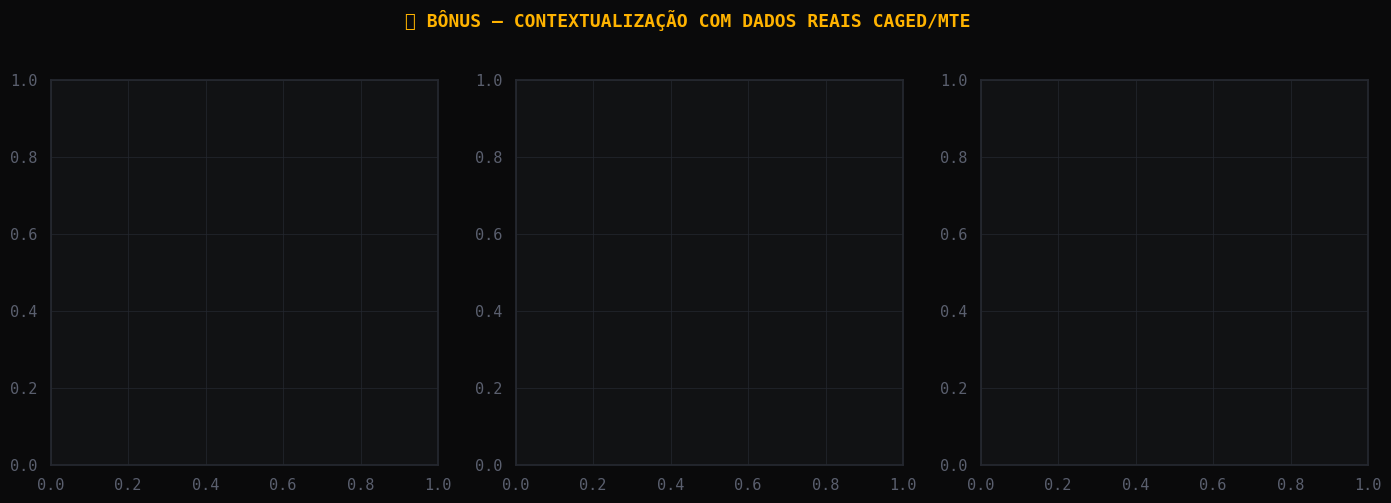

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('🌟 BÔNUS — CONTEXTUALIZAÇÃO COM DADOS REAIS CAGED/MTE',
             fontsize=13, fontweight='bold', color=AMBER, y=1.02)

# Gráfico 1: Gap empresa vs. nacional
ax = axes[0]
vals = [gap_nac_pct, gap_empresa]
bars = ax.bar(['Gap Nacional\n(CAGED)', 'Gap desta\nEmpresa'], vals,
              color=[BLUE, RED if gap_empresa > gap_nac_pct else AMBER], alpha=0.88, width=0.5)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
            f'{val:.1f}%', ha='center', fontsize=14, fontweight='bold', color='white')
ax.set_ylabel('Gap M→F (%)'); ax.set_title('Gap Salarial de Gênero:\nEmpresa vs. Média Nacional')
ax.set_ylim(0, 24)
ax.text(0.5, 0.06, 'Fonte: CAGED/MTE 2022–2025', transform=ax.transAxes,
        ha='center', fontsize=8, color=MUTED, style='italic')

# Gráfico 2: Evolução salarial TI Brasil
ax2 = axes[1]
ax2.plot(ti.index, ti.values, color=BLUE, marker='o', lw=2.5, label='CAGED — TI BR')
ax2.axhline(sal_empresa, color=AMBER, ls='--', lw=2, label=f'Esta empresa: R$ {sal_empresa:,.0f}')
ax2.fill_between(ti.index, ti.values, alpha=0.1, color=BLUE)
for x, y in zip(ti.index, ti.values):
    ax2.text(x, y+30, f'R${y/1000:.1f}k', ha='center', fontsize=8, color=BLUE)
ax2.set_xlabel('Ano'); ax2.set_ylabel('Salário Médio (R$)')
ax2.set_title('Evolução Salarial\nSetor TI/Comunicação Brasil')
ax2.legend(labelcolor='white', fontsize=9)
ax2.text(0.5, 0.04, 'Fonte: CAGED/MTE', transform=ax2.transAxes,
         ha='center', fontsize=8, color=MUTED, style='italic')

# Gráfico 3: Turnover vs. benchmark
ax3 = axes[2]
bench_l = ['Mercado BR\n(ref.)', 'Setor Tech\nBR (típico)', 'Esta\nEmpresa']
bench_v = [15.0, 18.0, taxa_media]
bench_c = [GREEN, AMBER, RED if taxa_media > 18 else AMBER]
bars3 = ax3.bar(bench_l, bench_v, color=bench_c, alpha=0.88, width=0.55)
for bar, val in zip(bars3, bench_v):
    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
             f'{val:.1f}%', ha='center', fontsize=13, fontweight='bold', color='white')
ax3.set_ylabel('Taxa de Turnover Anual (%)'); ax3.set_title('Turnover Empresa\nvs. Benchmark de Mercado')
ax3.set_ylim(0, 32)
ax3.text(0.5, 0.06, 'Ref: SHRM, LinkedIn, Glassdoor BR 2024',
         transform=ax3.transAxes, ha='center', fontsize=8, color=MUTED, style='italic')

plt.tight_layout()
plt.savefig('08_caged_benchmark.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
